<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-failure-prediction/blob/main/Modelling%20ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MSc Project - Modelling ML

This notebook contains code for MSc project on modelling time-to-failure of water mains. Machine learning regression models are trained - XGBoost, Random Forests, SVR and ANN. Deep learning models are also trained - RNN and LSTM.

# Import data and required packages

In [ ]:
# import packages

import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import max_error
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statistics
from sklearn.neural_network import MLPRegressor


In [ ]:
# mount Google Drive

drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


In [ ]:
# import data

attributes = pd.read_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding = "latin1")

X_train = pd.read_csv("/content/drive/MyDrive/MSc project/X_train.csv", encoding = "latin1")
X_valid = pd.read_csv("/content/drive/MyDrive/MSc project/X_valid.csv", encoding = "latin1")
X_test = pd.read_csv("/content/drive/MyDrive/MSc project/X_test.csv", encoding = "latin1")


y_train = pd.read_csv("/content/drive/MyDrive/MSc project/y_train.csv", encoding = "latin1")
y_valid = pd.read_csv("/content/drive/MyDrive/MSc project/y_valid.csv", encoding = "latin1")
y_test = pd.read_csv("/content/drive/MyDrive/MSc project/y_test.csv", encoding = "latin1")

In [ ]:
# convert categorical columns

X_train['Lining'] = X_train['Lining'].astype("category")
X_train['Surface'] = X_train['Surface'].astype("category")
X_train['Soil'] = X_train['Soil'].astype("category")
X_train['Material'] = X_train['Material'].astype("category")


X_valid['Lining'] = X_valid['Lining'].astype("category")
X_valid['Surface'] = X_valid['Surface'].astype("category")
X_valid['Soil'] = X_valid['Soil'].astype("category")
X_valid['Material'] = X_valid['Material'].astype("category")


X_test['Lining'] = X_test['Lining'].astype("category")
X_test['Surface'] = X_test['Surface'].astype("category")
X_test['Soil'] = X_test['Soil'].astype("category")
X_test['Material'] = X_test['Material'].astype("category")


In [ ]:
# convert to tidy data

X_train_tidy = pd.get_dummies(X_train)
X_valid_tidy = pd.get_dummies(X_valid)
X_test_tidy = pd.get_dummies(X_test)

In [ ]:
# normalise data

scaler = StandardScaler()


X_train_tidy['Diameter'] = scaler.fit_transform(X_train_tidy[['Diameter']])
X_train_tidy['Length'] = scaler.fit_transform(X_train_tidy[['Length']])
X_train_tidy['Soil_pH'] = scaler.fit_transform(X_train_tidy[['Soil_pH']])
X_train_tidy['Frost_days'] = scaler.fit_transform(X_train_tidy[['Frost_days']])
X_train_tidy['Hydrogen Ion'] = scaler.fit_transform(X_train_tidy[['Hydrogen Ion']])
X_train_tidy['Free chlorine'] = scaler.fit_transform(X_train_tidy[['Free chlorine']])
X_train_tidy['Age'] = scaler.fit_transform(X_train_tidy[['Age']])
X_train_tidy['Previous bursts'] = scaler.fit_transform(X_train_tidy[["Previous bursts"]])

X_valid_tidy['Diameter'] = scaler.fit_transform(X_valid_tidy[['Diameter']])
X_valid_tidy['Length'] = scaler.fit_transform(X_valid_tidy[['Length']])
X_valid_tidy['Soil_pH'] = scaler.fit_transform(X_valid_tidy[['Soil_pH']])
X_valid_tidy['Frost_days'] = scaler.fit_transform(X_valid_tidy[['Frost_days']])
X_valid_tidy['Hydrogen Ion'] = scaler.fit_transform(X_valid_tidy[['Hydrogen Ion']])
X_valid_tidy['Free chlorine'] = scaler.fit_transform(X_valid_tidy[['Free chlorine']])
X_valid_tidy['Age'] = scaler.fit_transform(X_valid_tidy[['Age']])
X_valid_tidy['Previous bursts'] = scaler.fit_transform(X_valid_tidy[["Previous bursts"]])

X_test_tidy['Diameter'] = scaler.fit_transform(X_test_tidy[['Diameter']])
X_test_tidy['Length'] = scaler.fit_transform(X_test_tidy[['Length']])
X_test_tidy['Soil_pH'] = scaler.fit_transform(X_test_tidy[['Soil_pH']])
X_test_tidy['Frost_days'] = scaler.fit_transform(X_test_tidy[['Frost_days']])
X_test_tidy['Hydrogen Ion'] = scaler.fit_transform(X_test_tidy[['Hydrogen Ion']])
X_test_tidy['Free chlorine'] = scaler.fit_transform(X_test_tidy[['Free chlorine']])
X_test_tidy['Age'] = scaler.fit_transform(X_test_tidy[['Age']])
X_test_tidy['Previous bursts'] = scaler.fit_transform(X_test_tidy[["Previous bursts"]])

# Modelling

In thi section, ML models are trained at default parameters. Additionally, models are evaluated using evaluation metrics obtained via bootstrapping.

### XGBoost

In [ ]:
# converting dataframe to DMatrix

import xgboost as xgb

xgb_train_tidy = xgb.DMatrix(X_train_tidy, y_train, enable_categorical=True)
xgb_valid_tidy = xgb.DMatrix(X_valid_tidy, y_valid, enable_categorical=True)
xgb_test_tidy = xgb.DMatrix(X_test_tidy, y_test, enable_categorical=True)




In [ ]:
# model training of XGBoost

params = {
    'objective': "reg:squarederror",
    'seed': 42

}


model_xgb = xgb.train(params = params, dtrain = xgb_train_tidy)

In [ ]:
# max error for XGBoost

preds = model_xgb.predict(xgb_test_tidy)

print((np.array(y_test) - preds).min())
print((np.array(y_test) - preds).max())

-14.994801701584908
20.336161394151922


In [ ]:
# calculate MAE using bootstrapping

MAE_XGBoost = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    xgb_test = xgb.DMatrix(X_test_bootstrap, y_test_bootrstrap, enable_categorical=True)

    preds = model_xgb.predict(xgb_test)

    MAE_bootstrap = mean_absolute_error(y_test_bootrstrap, preds)

    MAE_XGBoost.append(MAE_bootstrap)




In [ ]:
# calculate RMSE using bootstrapping

RMSE_XGBoost = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    xgb_test = xgb.DMatrix(X_test_bootstrap, y_test_bootrstrap, enable_categorical=True)

    preds = model_xgb.predict(xgb_test)

    RMSE_bootstrap = root_mean_squared_error(y_test_bootrstrap, preds)

    RMSE_XGBoost.append(RMSE_bootstrap)




In [ ]:
# claulctae R2 using bootstrapping

R2_XGBoost = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    xgb_test = xgb.DMatrix(X_test_bootstrap, y_test_bootrstrap, enable_categorical=True)

    preds = model_xgb.predict(xgb_test)

    R2_bootstrap = r2_score(y_test_bootrstrap, preds)

    R2_XGBoost.append(R2_bootstrap)


In [ ]:
# mean and SD for MAE

print(statistics.mean(MAE_XGBoost))
print(statistics.stdev(MAE_XGBoost))

4.580506386756897

In [ ]:
# mean and SD for RMSE

print(statistics.mean(RMSE_XGBoost))
print(statistics.stdev(RMSE_XGBoost))

5.617972005367279

In [ ]:
# meand and SD for R2

print(statistics.mean(R2_XGBoost))
print(statistics.stdev(R2_XGBoost))

0.2224479779601097

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_RF = RandomForestRegressor(random_state = 42)
model_RF.fit(X_train_tidy, y_train)
y_pred_RF = model_RF.predict(X_test_tidy)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
# max error for RF

preds = model_RF.predict(X_test_tidy)

print(max_error(y_test, preds))

15.860301369863006


In [ ]:
# MAE for RF

MAE_RF = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_RF.predict(X_test_bootstrap)

    MAE_bootstrap = mean_absolute_error(y_test_bootrstrap, preds)

    MAE_RF.append(MAE_bootstrap)


In [ ]:
# mean and sd of MAE

print(statistics.mean(MAE_RF))
print(statistics.stdev(MAE_RF))

4.6542211364333

In [ ]:
# RMSE for RF

RMSE_RF = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_RF.predict(X_test_bootstrap)

    RMSE_bootstrap = root_mean_squared_error(y_test_bootrstrap, preds)

    RMSE_RF.append(RMSE_bootstrap)


In [ ]:
statistics.mean(RMSE_RF)

5.698692495258689

In [ ]:
statistics.stdev(RMSE_RF)

0.08307529585481467

In [ ]:
# R2 for RF

R2_RF = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_RF.predict(X_test_bootstrap)

    R2_bootstrap = r2_score(y_test_bootrstrap, preds)

    R2_RF.append(R2_bootstrap)


In [ ]:
statistics.mean(R2_RF)

0.20192678563660804

In [ ]:
statistics.stdev(R2_RF)

0.021002036846513892

In [ ]:
MAE_RF = pd.DataFrame(MAE_RF)
MAE_RF.to_csv("/content/drive/MyDrive/MSc project/Experiment 1/MAE_RF.csv", encoding ='latin1', index=False)

In [ ]:
RMSE_RF = pd.DataFrame(RMSE_RF)
RMSE_RF.to_csv("/content/drive/MyDrive/MSc project/Experiment 1/RMSE_RF.csv", encoding ='latin1', index=False)

In [ ]:
R2_RF = pd.DataFrame(R2_RF)
R2_RF.to_csv("/content/drive/MyDrive/MSc project/Experiment 1/R2_RF.csv", encoding ='latin1', index=False)

### Support Vector Regression

In [ ]:
from sklearn.svm import SVR

model_SVR = SVR()
model_SVR.fit(X_train_tidy, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [ ]:
# max error for SVR


preds = model_SVR.predict(X_test_tidy)

print((np.array(y_test) - preds).min())
print((np.array(y_test) - preds).max())

-10.97322177215198
22.520443944442576


In [ ]:
MAE_SVR = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_SVR.predict(X_test_bootstrap)

    MAE_bootstrap = mean_absolute_error(y_test_bootrstrap, preds)

    MAE_SVR.append(MAE_bootstrap)

In [ ]:


statistics.mean(MAE_SVR)

4.706420649855823

In [ ]:
statistics.stdev(MAE_SVR)

0.08187276400889291

In [ ]:
RMSE_SVR = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_SVR.predict(X_test_bootstrap)

    RMSE_bootstrap = root_mean_squared_error(y_test_bootrstrap, preds)

    RMSE_SVR.append(RMSE_bootstrap)

In [ ]:
statistics.mean(RMSE_SVR)

5.894148645937151

In [ ]:
statistics.stdev(RMSE_SVR)

0.09326032186733413

In [ ]:
R2_SVR = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_SVR.predict(X_test_bootstrap)

    R2_bootstrap = r2_score(y_test_bootrstrap, preds)

    R2_SVR.append(R2_bootstrap)

In [ ]:
statistics.mean(R2_SVR)

0.1452882064738485

In [ ]:
statistics.stdev(R2_SVR)

0.01538112320588628

In [ ]:
MAE_SVR = pd.DataFrame(MAE_SVR)
MAE_SVR.to_csv("/content/drive/MyDrive/MSc project/Experiment 1/MAE_SVR.csv", encoding ='latin1', index=False)

In [ ]:
RMSE_SVR = pd.DataFrame(RMSE_SVR)
RMSE_SVR.to_csv("/content/drive/MyDrive/MSc project/Experiment 1/RMSE_SVR.csv", encoding ='latin1', index=False)

In [ ]:
R2_SVR = pd.DataFrame(R2_SVR)
R2_SVR.to_csv("/content/drive/MyDrive/MSc project/Experiment 1/R2_SVR.csv", encoding ='latin1', index=False)

### ANN

In [ ]:
# model training for MLP

model_ANN = MLPRegressor(random_state = 42)

model_ANN.fit(X_train_tidy,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(random_state=42)

In [ ]:
# max residual error for ANN


preds = model_ANN.predict(X_test_tidy)

print((np.array(y_test) - preds).min())
print((np.array(y_test) - preds).max())

-15.64640646933507
30.55565348560684


In [ ]:
# bootstrapping for MAE

MAE_ANN = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_ANN.predict(X_test_bootstrap)

    MAE_bootstrap = mean_absolute_error(y_test_bootrstrap, preds)

    MAE_ANN.append(MAE_bootstrap)

In [ ]:
# mean and sd for MAE

print(statistics.mean(MAE_ANN))
print(statistics.stdev(MAE_ANN))

4.596823571124361

In [ ]:
# bootstrapping for RMSE

RMSE_ANN = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_ANN.predict(X_test_bootstrap)

    RMSE_bootstrap = root_mean_squared_error(y_test_bootrstrap, preds)

    RMSE_ANN.append(RMSE_bootstrap)

In [ ]:
# meand and sd for RMSE

statistics.mean(RMSE_ANN)

statistics.stdev(RMSE_ANN)

5.6822974161067075

In [ ]:
R2_ANN = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_ANN.predict(X_test_bootstrap)

    R2_bootstrap = r2_score(y_test_bootrstrap, preds)

    R2_ANN.append(R2_bootstrap)

In [ ]:
statistics.mean(R2_ANN)

0.2069341817367622

In [ ]:
statistics.stdev(R2_Ann)

0.019974893669718247

Finally, t-test is performed to test whether the metrics the difference in evaluation metrics for each model is statistcially significant.

In [ ]:
MAE_XGBoost = pd.read_csv("/content/drive/MyDrive/MSc project/Experiment 1/MAE_XGBoost.csv", encoding = "latin1")

In [ ]:
MAE_XGBoost

,0
0,4.537788
1,4.539618
2,4.540940
3,4.594134
4,4.558623
...,...
995,4.495206
996,4.573072
997,4.583928
998,4.429003


In [ ]:
# paired t-test MAE
from scipy.stats import ttest_rel

ttest_rel(MAE_XGBoost, MAE_ANN)

TtestResult(statistic=array([-4.57579109]), pvalue=array([5.34050881e-06]), df=array([999]))

# Parameter tuning

In this section, parameter tuning is done for the best performing model - XGBoost.

In [ ]:
# converting dataframe to DMatrix

import xgboost as xgb

xgb_train_tidy = xgb.DMatrix(X_train_tidy, y_train, enable_categorical=True)
xgb_test_tidy = xgb.DMatrix(X_test_tidy, y_test, enable_categorical=True)

In [ ]:
# model training of XGBoost

params = {
    'objective': "reg:squarederror",
    'seed': 42,
    'learning_rate': 0.2,
    'gamma': 2.5,
    'max_depth': 3
}


model_xgb = xgb.train(params = params, dtrain = xgb_train_tidy)

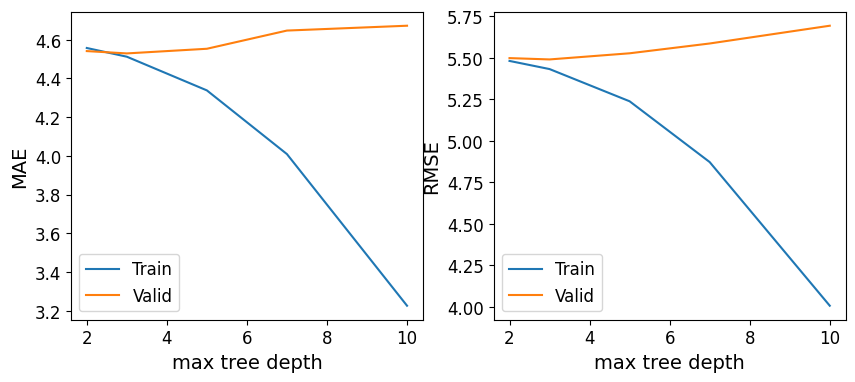

In [ ]:
# max depth

max_depth = [2, 3, 5, 7, 10]

MAE = [4.557, 4.512, 4.338, 4.009, 3.226]
RMSE = [5.480, 5.431, 5.237, 4.871, 4.006 ]

valid_MAE = [4.541, 4.529, 4.553, 4.647, 4.672]
valid_RMSE = [5.497, 5.489, 5.526, 5.585, 5.692]

fix, ax = plt.subplots(1,2, figsize = [10,4])

ax[0].plot(max_depth, MAE, label = "Train")
ax[0].plot(max_depth, valid_MAE, label = "Valid")
ax[0].legend(fontsize = 12)
ax[0].set_xlabel("max tree depth", fontsize = 14)
ax[0].set_ylabel("MAE", fontsize = 14)
ax[0].tick_params(labelsize=12)

ax[1].plot(max_depth, RMSE, label = "Train")
ax[1].plot(max_depth, valid_RMSE, label = "Valid")
ax[1].legend(fontsize = 12)
ax[1].set_xlabel("max tree depth", fontsize = 14)
ax[1].set_ylabel("RMSE", fontsize = 14)
ax[1].tick_params(labelsize = 12)

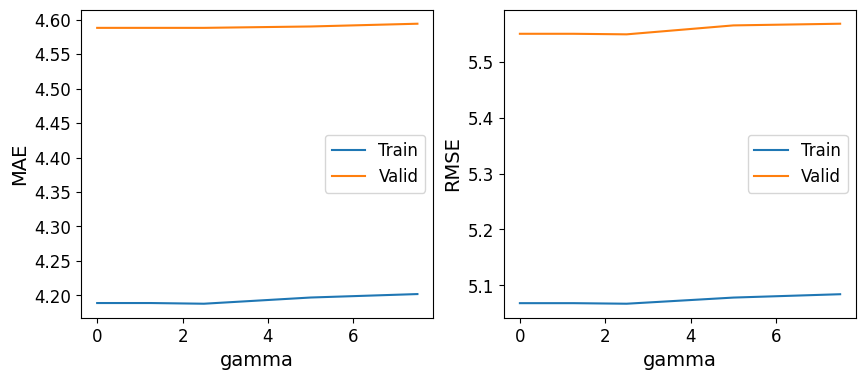

In [ ]:
# gamma

gamma = [0, 1.25, 2.5, 5.0, 7.5]

MAE = [4.189, 4.189, 4.188, 4.197, 4.202]
RMSE = [5.068, 5.068, 5.067, 5.078, 5.084 ]

valid_MAE = [4.588, 4.588, 4.588, 4.59, 4.594]
valid_RMSE = [5.550, 5.550, 5.549, 5.565, 5.568]

fix, ax = plt.subplots(1,2, figsize = [10,4])

ax[0].plot(gamma, MAE, label = "Train")
ax[0].plot(gamma, valid_MAE, label = "Valid")
ax[0].legend(fontsize = 12)
ax[0].set_xlabel("gamma", fontsize = 14)
ax[0].set_ylabel("MAE", fontsize = 14)
ax[0].tick_params(labelsize=12)

ax[1].plot(gamma, RMSE, label = "Train")
ax[1].plot(gamma, valid_RMSE, label = "Valid")
ax[1].legend(fontsize = 12)
ax[1].set_xlabel("gamma", fontsize = 14)
ax[1].set_ylabel("RMSE", fontsize = 14)
ax[1].tick_params(labelsize = 12)


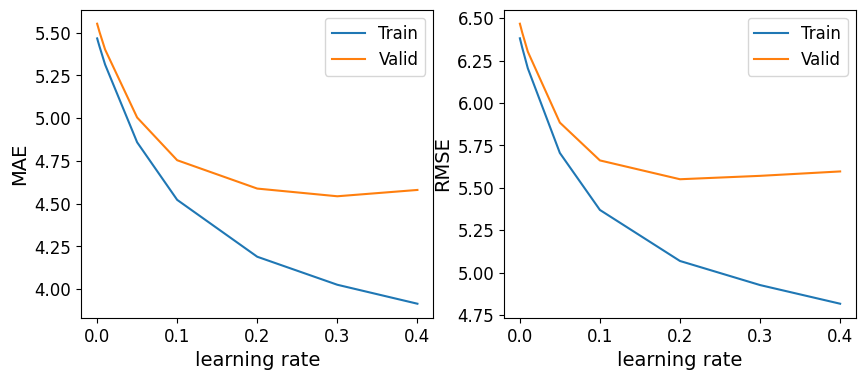

In [ ]:
# learning rate

eta = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4]

MAE = [5.467, 5.464, 5.452, 5.420, 5.314, 4.859, 4.522, 4.189, 4.025, 3.914 ]
RMSE = [6.381, 6.377, 6.364, 6.326, 6.204, 5.705, 5.369, 5.068, 4.926, 4.816 ]

valid_MAE = [5.553, 5.549, 5.538, 5.505, 5.402, 5.004, 4.754, 4.588, 4.543, 4.580 ]
valid_RMSE = [6.467, 6.463, 6.451, 6.415, 6.302, 5.884, 5.661, 5.550, 5.570, 5.596 ]

fix, ax = plt.subplots(1,2, figsize = [10,4])

ax[0].plot(eta, MAE, label = "Train")
ax[0].plot(eta, valid_MAE, label = "Valid")
ax[0].legend(fontsize = 12)
ax[0].set_xlabel("learning rate", fontsize = 14)
ax[0].set_ylabel("MAE", fontsize = 14)
ax[0].tick_params(labelsize=12)

ax[1].plot(eta, RMSE, label = "Train")
ax[1].plot(eta, valid_RMSE, label = "Valid")
ax[1].legend(fontsize = 12)
ax[1].set_xlabel("learning rate", fontsize = 14)
ax[1].set_ylabel("RMSE", fontsize = 14)
ax[1].tick_params(labelsize = 12)


# Feature Importance

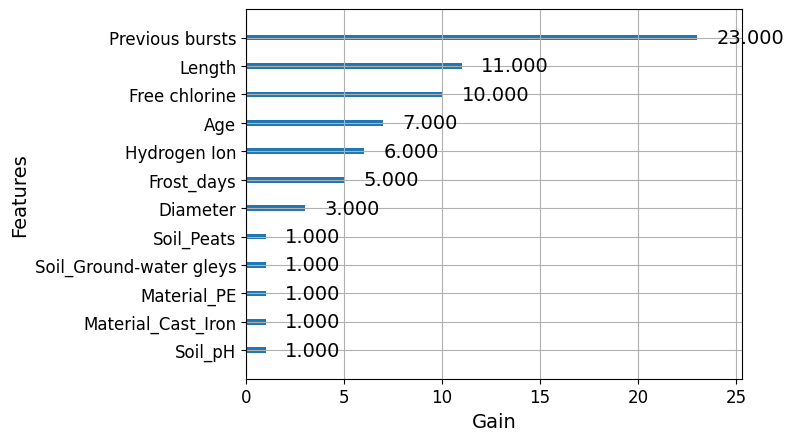

In [ ]:
from xgboost import plot_importance

ax = plot_importance(model_xgb, importance_type="weight", max_num_features=100)
ax.set_xlabel("Gain", fontsize = 14)
ax.set_ylabel("Features", fontsize = 14)
ax.tick_params(labelsize=12)
ax.set_title("")
for text in ax.texts:
    text.set_text(f"{float(text.get_text()):.3f}")
    text.set_fontsize(14)

plt.show()
